# Task 1 Problem Definition

Problema actuala este prezicerea pretului unui ETF (Exchange-Traded Fund) pe baza datelor istorice. Acest lucru poate fi realizat prin utilizarea unor modele de invatare automata (machine learning) care analizeaza datele istorice ale preturilor ETF-urilor pentru a face predictii despre preturile viitoare.
Putem si clasifica aceste preturi in categorii, cum ar fi "crestere", "scadere" sau "stabil", in functie de evolutia lor in timp. Acest tip de clasificare poate ajuta investitorii sa ia decizii informate despre cum sa isi gestioneze portofoliul de investitii.
Acest lucru e util pentru investitori, deoarece le permite sa anticipeze evolutia preturilor ETF-urilor si sa ia decizii informate despre cum sa isi gestioneze portofoliul de investitii. De exemplu, daca modelul prezice o crestere a pretului unui ETF, investitorii ar putea decide sa cumpere mai multe 
unitati din acel ETF pentru a profita de potentialele castiguri. In schimb, daca modelul prezice o scadere a pretului, investitorii ar putea decide sa vanda unitatile pe care le detin pentru a evita pierderile.

Am ales aceasta problema deoarece prezicerea preturilor ETF-urilor este o provocare interesanta si relevanta in domeniul finantelor, iar utilizarea modelelor de invatare automata poate oferi informatii valoroase pentru investitori. De asemenea, clasificarea preturilor in categorii poate ajuta la simplificarea procesului de
luare a deciziilor pentru investitori, oferindu-le o perspectiva mai clara asupra evolutiei pietei.


# Task 2 EDA, Data Analysis

Structura datelor e in felul acesta: Date,Open,High,Low,Close,Adj Close,Volume
Nu avem neaparat date de clasificare, mai mult date pentru regresii. pentru acest fapt, cream categorii precum stabilitate: "stabil", "crestere", "scadere". 
Ca preprocesare a datelor, vom luam cele mai performante 20 de etf-uri pe baza indexului sharpe (returnare per variabilitate) cu formula:

 returns.mean() / returns.std() * (252 ** 0.5)  # annualized
 
Datele cu coloane lipsa au fost eliminate, lafel si anomaliile care au fost cu 4 deviatii standard peste ratele normale de volum si range(pret high - pret low)


In [1]:
%load_ext autoreload
%autoreload 2



import os

from data_handling.Data_Of_Best_N_ETFs import build_dataset


df = build_dataset(os.getcwd() + "/etfs")

print(df.head())


Top ETFs by Sharpe:

ticker  rows   sharpe
   RTL  3165 2.578481
   CEZ  5051 1.964643
   PLC  4917 1.959869
   PSM  2547 1.542505
   CSB  4932 1.143445
   OLD  2590 1.069146
  CLIX   597 1.004401
   QUS  2108 0.918902
   CIL  4884 0.917543
  TQQQ  2552 0.845863
  TECL  2833 0.806727
   XSW  2140 0.769820
  EMTY   597 0.760238
  FTEC  1620 0.750974
  XITK  1061 0.745514
  ARKW  1386 0.745190
   IWY  2646 0.741495
  REGL  1104 0.738276
  PSCH  2515 0.737670
  VONG  2398 0.728394

Dataset shape : (51643, 8)
Columns       : ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Ticker']
Tickers       : 20
Date range    : 2000-01-03 → 2020-04-01
        Date       Open       High        Low      Close  Adj Close   Volume  \
0 2014-09-30  20.059999  20.059999  19.920000  19.990000  16.921232   5500.0   
1 2014-10-01  19.650000  19.660000  19.551001  19.551001  16.549625   8100.0   
2 2014-10-02  19.400000  19.450001  19.400000  19.430000  16.447199  15500.0   
3 2014-10-03  20.110

,Date,Open,High,Low,Close,Adj Close,Volume,daily_range,volume_zscore,range_zscore,Return_Pct,Target_Reg,Target_Cls
0,2014-10-28,19.709999,20.080000,19.709999,20.080000,16.997416,6000.0,1.842634,-0.126043,0.827628,2.136318,-1.394426,stabil
1,2014-10-29,19.910000,19.910000,19.730000,19.799999,16.760399,5000.0,0.909092,-0.350883,-0.256176,-1.394426,0.050506,stabil
2,2014-10-30,19.770000,19.809999,19.580000,19.809999,16.768864,5300.0,1.161028,-0.165485,-0.019431,0.050506,2.624939,crestere
3,2014-10-31,20.309999,20.340000,20.309999,20.330000,17.209036,1300.0,0.147569,-1.308134,-1.178849,2.624939,0.344317,stabil
4,2014-11-03,20.440001,20.530001,20.400000,20.400000,17.268290,2200.0,0.637260,-0.956469,-0.566837,0.344317,0.000000,stabil
...,...,...,...,...,...,...,...,...,...,...,...,...,...
44668,2020-03-25,80.190002,82.910004,78.459999,79.839996,79.839996,36200.0,5.573653,-0.620309,0.095157,0.680950,5.711430,crestere
44669,2020-03-26,80.620003,84.459999,80.620003,84.400002,84.400002,80400.0,4.549759,0.682806,-0.426876,5.711430,-3.199057,scadere
44670,2020-03-27,82.389999,83.500000,80.940002,81.699997,81.699997,50900.0,3.133412,-0.154752,-1.078180,-3.199057,2.190944,crestere
44671,2020-03-30,81.949997,83.489998,81.949997,83.489998,83.489998,28600.0,1.844533,-0.783007,-1.580434,2.190944,-1.676849,stabil


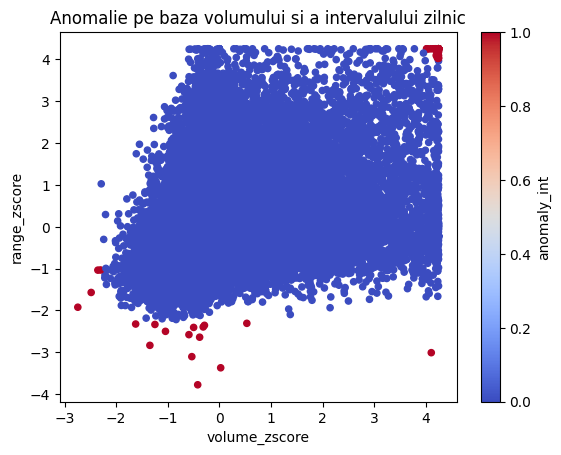

In [2]:
df.dropna()
    

from data_handling.Data_Of_Best_N_ETFs import add_targets, add_zscores




df = add_zscores(df, 20)
df = add_targets(df)
threshold = 4.5
threshold_min: float = -2.3
# flag as anomaly if either z-score is beyond 'threshold' standard deviations
df["anomaly"] = (
    (df["volume_zscore"] > threshold) | (df["volume_zscore"] < threshold_min)
) | (
    (df["range_zscore"] > threshold) | (df["range_zscore"] < threshold_min)
) | (
    (df["volume_zscore"].abs() > threshold - 0.5) & (df["range_zscore"].abs() > threshold - 0.5)
)
df["anomaly_int"] = df["anomaly"].astype(int)  # True→1, False→0
df.plot.scatter(x="volume_zscore", y="range_zscore", c="anomaly_int", colormap="coolwarm", title="Anomalie pe baza volumului si a intervalului zilnic")

df = df[df['anomaly_int'] == 0]
df.drop(columns=["anomaly", "anomaly_int"])


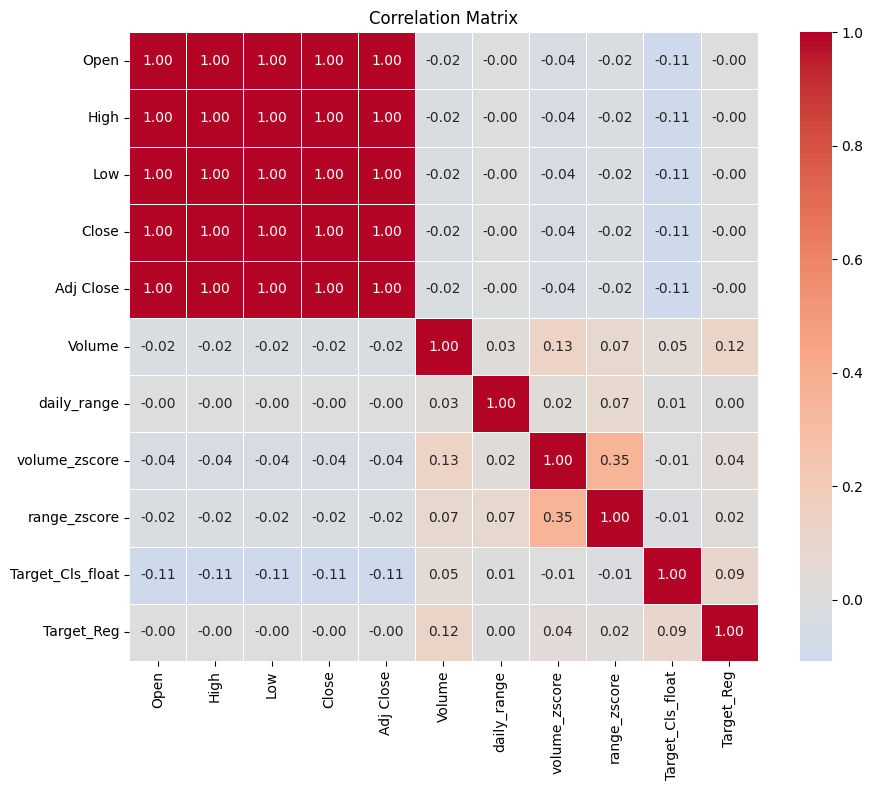

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# pick only numeric columns

df["Target_Cls_float"] = df["Target_Cls"].map({"crestere": 2, "scadere": 0, "stabil": 1})
numeric_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume", 
                "daily_range", "volume_zscore", "range_zscore", "Target_Cls_float", "Target_Reg"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,          # show numbers inside cells
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",     # red=positive, blue=negative correlation
    center=0,            # white at 0
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Putem observa cum Open, High, Low, Close si Adj_close sunt corelata cu 1, deci putem da drop la toate inafara de una pentru a nu da aceeasi informatie de 2 ori modelului.

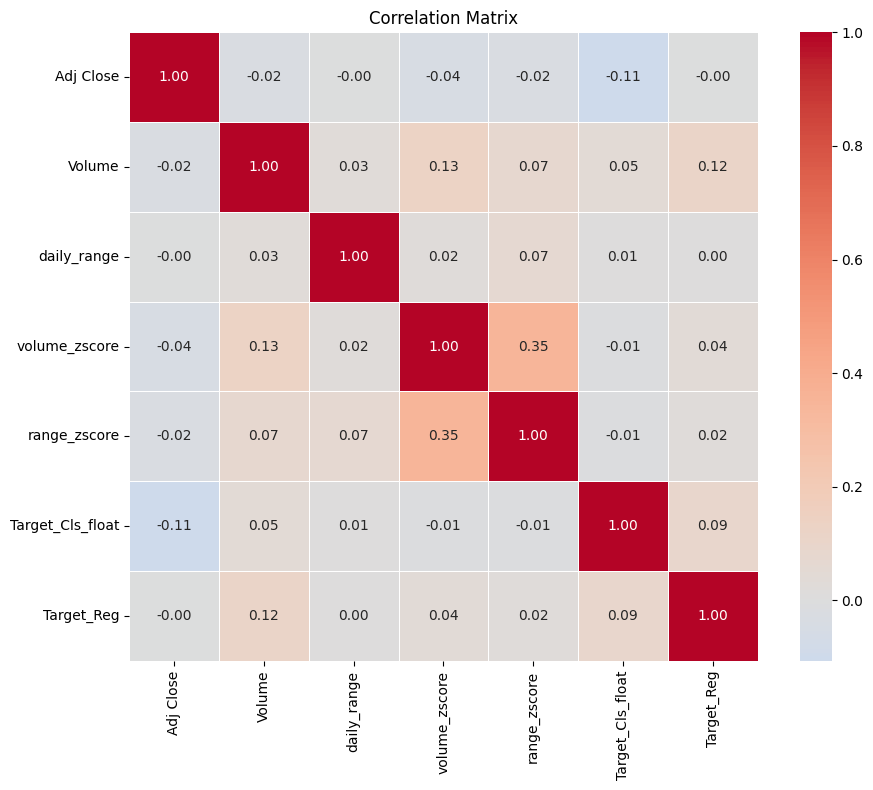

In [4]:
numeric_cols = [ "Adj Close", "Volume", 
                "daily_range", "volume_zscore", "range_zscore", "Target_Cls_float", "Target_Reg"]
df.drop(columns=["Open", "High", "Low", "Close"], inplace=True)
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,          # show numbers inside cells
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",     # red=positive, blue=negative correlation
    center=0,            # white at 0
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Task 4 Implementare si training

Modele de regresie (Acum putem da drop la anomalii, considerand ca le-am eliminat)


In [5]:
df.head()
df.drop(columns=["anomaly", "anomaly_int"], inplace=True)


In [ ]:


from comparison_programs.Run_And_Compare_Classifier_Models import compare_classifiers
from comparison_programs.run_and_compare_regression_models import compare_regressors


FEATURES = ["Adj Close", "Volume", "daily_range", "volume_zscore", "range_zscore"]

results_classifiers = compare_classifiers(df, FEATURES)
results_regressors = compare_regressors(df, FEATURES)

d:\Facultate\AN_III\Semestrul_2\SI\Proiect_ML\proiect-ml-JustDragos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Facultate\AN_III\Semestrul_2\SI\Proiect_ML\proiect-ml-JustDragos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


 Naive Bayes
   val  → acc=0.434  prec=0.416  rec=0.434  f1=0.412
   test → acc=0.917  prec=0.854  rec=0.917  f1=0.881
 Logistic Regression
   val  → acc=0.267  prec=0.618  rec=0.267  f1=0.193
   test → acc=0.822  prec=0.880  rec=0.822  f1=0.848
 Decision Tree
   val  → acc=0.466  prec=0.438  rec=0.466  f1=0.448
   test → acc=0.834  prec=0.857  rec=0.834  f1=0.845
 Random Forest
   val  → acc=0.562  prec=0.484  rec=0.562  f1=0.487
   test → acc=0.918  prec=0.878  rec=0.918  f1=0.882
 SVM
   val  → acc=0.327  prec=0.529  rec=0.327  f1=0.317
   test → acc=0.819  prec=0.866  rec=0.819  f1=0.841
 KNN
   val  → acc=0.501  prec=0.467  rec=0.501  f1=0.480
   test → acc=0.907  prec=0.860  rec=0.907  f1=0.878


d:\Facultate\AN_III\Semestrul_2\SI\Proiect_ML\proiect-ml-JustDragos\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:53:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 XGBoost
   val  → acc=0.532  prec=0.473  rec=0.532  f1=0.487
   test → acc=0.917  prec=0.879  rec=0.917  f1=0.884
 CatBoost
   val  → acc=0.510  prec=0.479  rec=0.510  f1=0.479
   test → acc=0.917  prec=0.875  rec=0.917  f1=0.884


# 4.1 Problems: 
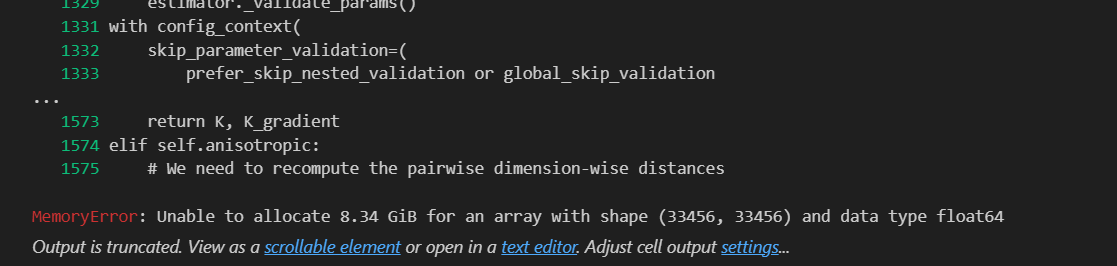

Nu putem folosi Gaussian Process deoarece se creeaza o matrice de probabilitati mult prea mare (8GB), de aceea nu il luam in considerare pe acest dataset, chiar daca ar fi fost printre cele mai bune. Nu avem (eu nu am) destula memorie.

# 4.2 Probleme:
Daca folosim macro pentru calculul f1, avem un f1 foarte scazut. Acest lucru se intampla deoarece datele nu sunt echilibrate, in sensul ca avem etf-uri stabile (sub 2% variatie pe zi) in majoritatea cazurilor, ceea ce nu este luat in considerare la macro. De aceea trebuie sa folosim weight, adica daca avem 90% cazuri stabile, sa zicem ca aceste cazuri stabile sunt mult mai importante: 0.9 * frecv_stabil, iar cele de crestere, aproximativ 0.05. Vor fi calculate pe ideea 0.05 * frecv_creste.

# 4.3 Probleme:
La SVR daca datele nu sunt scalate, atunci el devine cel mai slab model. Pentru a fixa acest lucru, am aplicat un standard scaler. Lafel se intampla si la Linear Regression Classifier, SVM si KNN.

# Task 5: Fine Tunning

In [ ]:
from comparison_programs.tune_top5 import tune_top5

FEATURES = ["Adj Close", "Volume", "daily_range", "volume_zscore", "range_zscore"]

# results comes from your earlier compare_classifiers call
tuning_results = tune_top5(results, df, FEATURES)

ModuleNotFoundError: No module named 'comparison_programs.tune_top5'